# Stage 1 – λ=50/100 comparison (seasonal vs battery‑equivalent)


In [17]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

YEAR = 1985

RUNS = {
    "lambda50_seasonal": "stagel_3month_lamba_2_seasonal",
    "lambda50_add_battery": "stagel_3month_lamba_20_add_battery",
    "lambda500_seasonal": "stagel_3month_lamba_5_seasonal",
    "lambda500_add_battery": "stagel_3month_lamba_20_add_battery",
}

output_root = Path("acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019")
if not output_root.exists():
    output_root = Path.cwd().parent / "outputs" / "historical_1980_2019"

print("Year:", YEAR)
print("Runs:", RUNS)
print("output_root:", output_root)


Year: 1985
Runs: {'lambda50_seasonal': 'stagel_3month_lamba_2_seasonal', 'lambda50_add_battery': 'stagel_3month_lamba_20_add_battery', 'lambda500_seasonal': 'stagel_3month_lamba_5_seasonal', 'lambda500_add_battery': 'stagel_3month_lamba_20_add_battery'}
output_root: /home/fs01/jl2966/acorn-julia2/acorn-julia/runs/low_RE_mod_elec_iter0/outputs/historical_1980_2019


In [18]:

# --- Helpers ----------------------------------------------------------------

def _strip_tz(idx):
    if hasattr(idx, 'tz') and idx.tz is not None:
        return idx.tz_convert(None)
    return idx


def tidy_storage_df(df: pd.DataFrame, value_name: str) -> pd.DataFrame:
    meta_cols = [c for c in ["bus_id", "asset_type", "zone", "is_seasonal"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def tidy_bus_df(path: Path, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    meta_cols = [c for c in ["bus_id", "zone"] if c in df.columns]
    value_cols = [c for c in df.columns if c not in meta_cols]
    tidy = df.melt(id_vars=meta_cols, value_vars=value_cols,
                   var_name="timestamp", value_name=value_name)
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    tidy = tidy.dropna(subset=["timestamp"])
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce").fillna(0.0)
    return tidy


def total_ts(df: pd.DataFrame, value_name: str) -> pd.Series:
    return df.groupby("timestamp")[value_name].sum()


def load_seasonal_soc(run_dir: Path, year: int) -> pd.Series:
    p = run_dir / f"storage_state_seasonal_{year}.csv"
    if not p.exists():
        return pd.Series(dtype=float)
    df = pd.read_csv(p)
    if df.empty:
        return pd.Series(dtype=float)
    cols = [c for c in df.columns if c not in ("zone",)]
    df = df[cols]
    if not df.empty and df.iloc[0, 0] == "bus_id":
        df = df.iloc[1:]
    value_cols = [c for c in df.columns if c != "bus_id"]
    df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")
    soc = df[value_cols].sum(axis=0)
    soc.index = pd.to_datetime(soc.index, errors="coerce")
    soc = soc.dropna()
    if hasattr(soc.index, 'tz') and soc.index.tz is not None:
        soc.index = soc.index.tz_convert(None)
    return soc


def safe_sum(series: pd.Series) -> float:
    return pd.to_numeric(series, errors="coerce").fillna(0.0).sum()


In [19]:

# --- Load all runs ----------------------------------------------------------
run_data = {}
for label, name in RUNS.items():
    run_dir = output_root / name
    run_data[label] = {
        "charge_base": tidy_storage_df(pd.read_csv(run_dir / f"charge_base_{YEAR}.csv"), "charge"),
        "discharge_base": tidy_storage_df(pd.read_csv(run_dir / f"discharge_base_{YEAR}.csv"), "discharge"),
        "charge_seasonal": tidy_storage_df(pd.read_csv(run_dir / f"charge_seasonal_{YEAR}.csv"), "charge"),
        "discharge_seasonal": tidy_storage_df(pd.read_csv(run_dir / f"discharge_seasonal_{YEAR}.csv"), "discharge"),
        "load_shed": tidy_bus_df(run_dir / f"load_shedding_{YEAR}.csv", "load_shedding"),
        "wind_curt": tidy_bus_df(run_dir / f"wind_curtailment_{YEAR}.csv", "wind_curtailment"),
        "solar_curt": tidy_bus_df(run_dir / f"solar_curtailment_{YEAR}.csv", "solar_curtailment"),
        "soc_seasonal": load_seasonal_soc(run_dir, YEAR),
    }

print("Loaded:", list(run_data.keys()))


Loaded: ['lambda50_seasonal', 'lambda50_add_battery', 'lambda500_seasonal', 'lambda500_add_battery']


## A) Annual totals (energy, curtailment, load shedding)


In [20]:

rows = []
for label, data in run_data.items():
    base_dis = total_ts(data["discharge_base"], "discharge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")
    base_ch = total_ts(data["charge_base"], "charge")
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    ls = total_ts(data["load_shed"], "load_shedding")
    wind = total_ts(data["wind_curt"], "wind_curtailment")
    solar = total_ts(data["solar_curt"], "solar_curtailment")

    rows.append({
        "run": label,
        "base_charge_MWh": safe_sum(base_ch),
        "base_discharge_MWh": safe_sum(base_dis),
        "seasonal_charge_MWh": safe_sum(seas_ch),
        "seasonal_discharge_MWh": safe_sum(seas_dis),
        "load_shed_MWh": safe_sum(ls),
        "wind_curt_MWh": safe_sum(wind),
        "solar_curt_MWh": safe_sum(solar),
    })

summary = pd.DataFrame(rows)
for c in summary.columns[1:]:
    summary[c] = summary[c].round(2)

display(summary)


,run,base_charge_MWh,base_discharge_MWh,seasonal_charge_MWh,seasonal_discharge_MWh,load_shed_MWh,wind_curt_MWh,solar_curt_MWh
0,lambda50_seasonal,54513.12,44355.94,71181.14,459825.27,611196.41,7098992.36,10808580.19
1,lambda50_add_battery,328231.38,249644.63,0.00,0.00,818316.19,5809141.76,11981928.93
2,lambda500_seasonal,315230.84,239894.23,0.00,220741.97,630741.52,7126807.21,10658998.38
3,lambda500_add_battery,328231.38,249644.63,0.00,0.00,818316.19,5809141.76,11981928.93


## B) Storage activity (base vs seasonal)


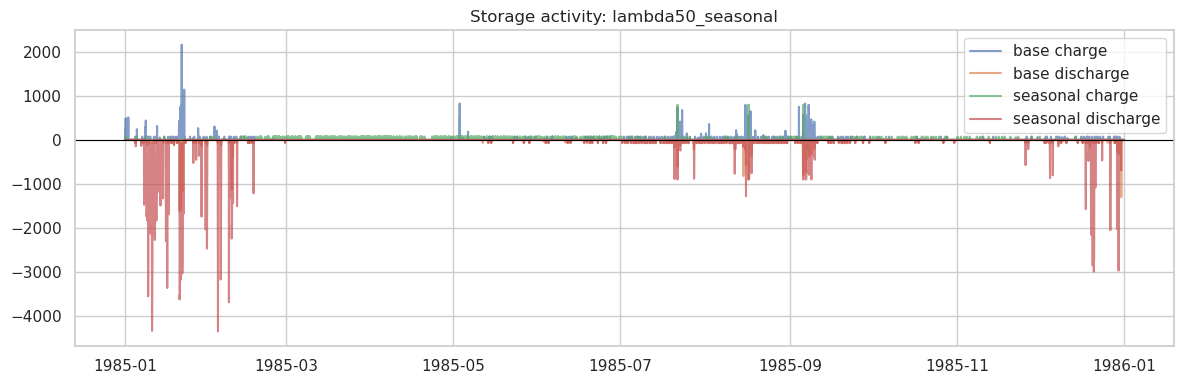

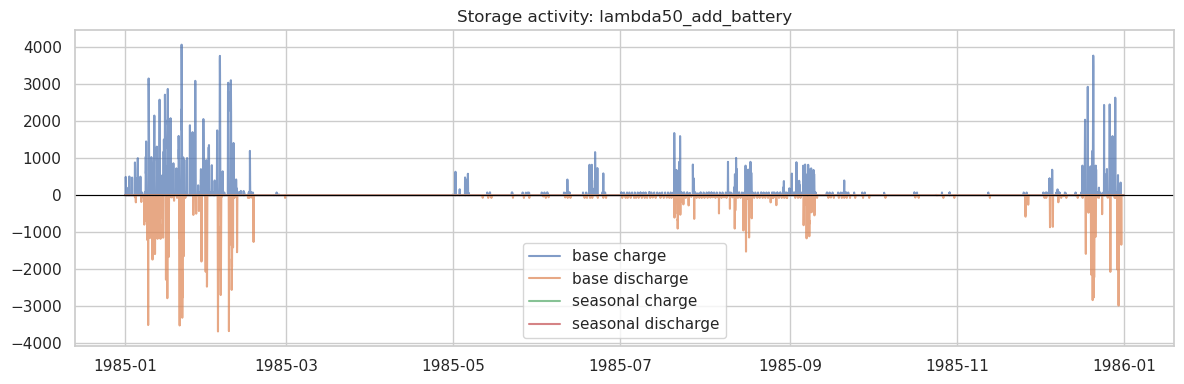

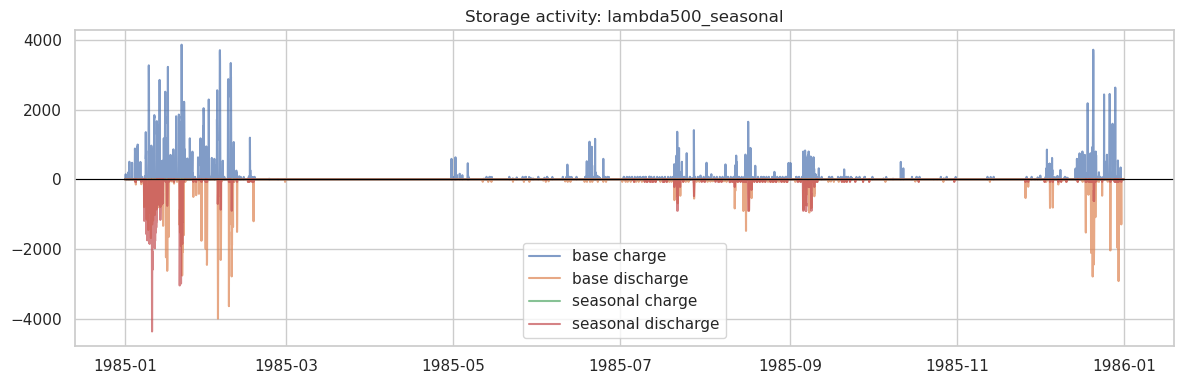

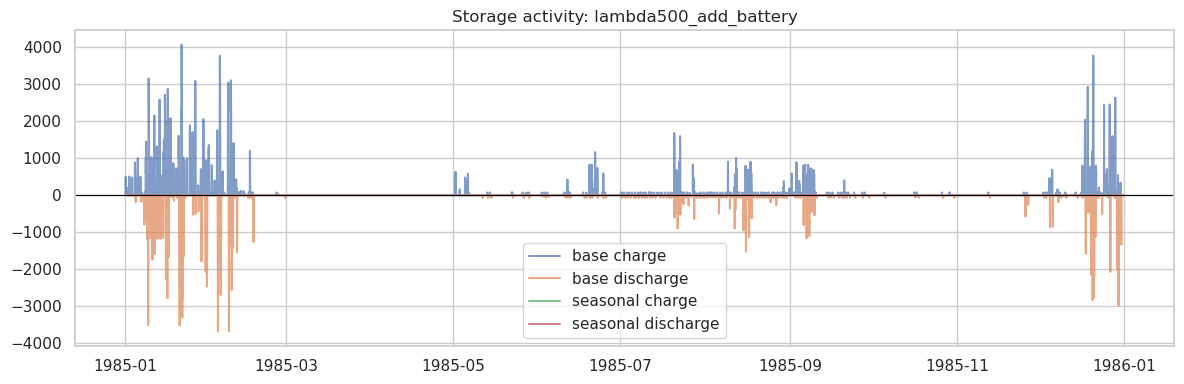

In [21]:

for label, data in run_data.items():
    base_ch = total_ts(data["charge_base"], "charge")
    base_dis = total_ts(data["discharge_base"], "discharge")
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")

    fig, ax = plt.subplots(1, 1, figsize=(12,4))
    ax.plot(base_ch.index, base_ch.values, label="base charge", alpha=0.7)
    ax.plot(base_dis.index, -base_dis.values, label="base discharge", alpha=0.7)
    ax.plot(seas_ch.index, seas_ch.values, label="seasonal charge", alpha=0.7)
    ax.plot(seas_dis.index, -seas_dis.values, label="seasonal discharge", alpha=0.7)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_title(f"Storage activity: {label}")
    ax.legend()
    plt.tight_layout()
    plt.show()


## C) Load shedding (time series + top buses)


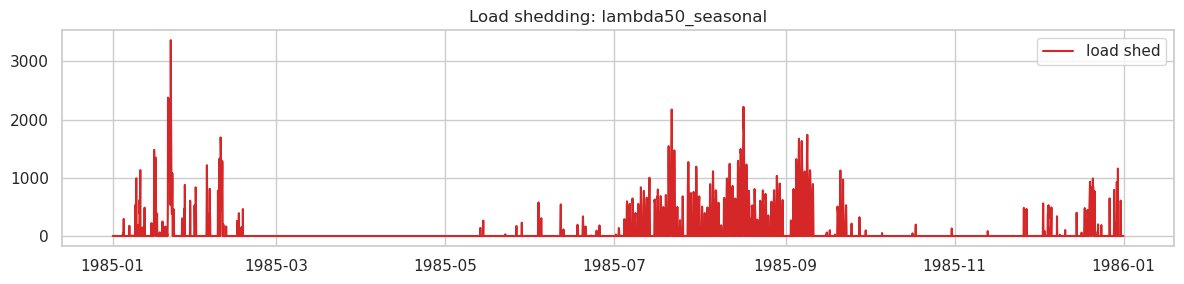

lambda50_seasonal – top 15 shedding buses


,bus_id,load_shedding
0,80,603713.075663
1,77,2932.298136
2,75,2734.468902
3,76,1816.569928
4,37,0.000000
5,38,0.000000
6,43,0.000000
7,44,0.000000
8,45,0.000000
9,46,0.000000


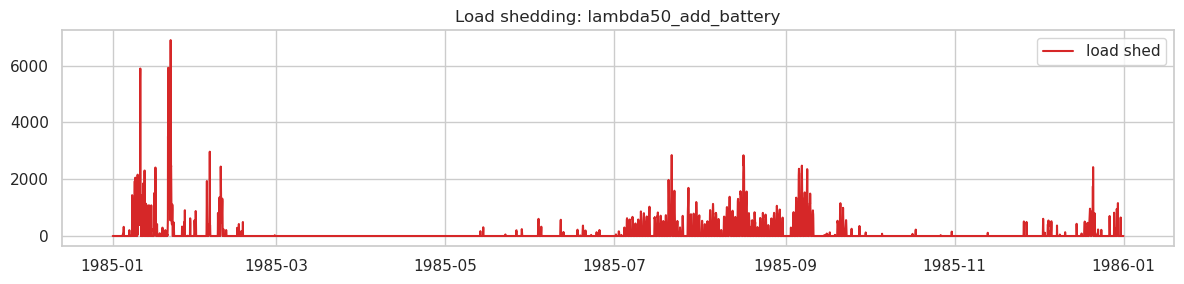

lambda50_add_battery – top 15 shedding buses


,bus_id,load_shedding
0,80,626672.612974
1,52,51505.360412
2,53,44813.509915
3,79,44734.584382
4,82,17773.420821
5,77,12318.414086
6,76,9995.772081
7,81,6164.250565
8,75,4338.265391
9,37,0.000000


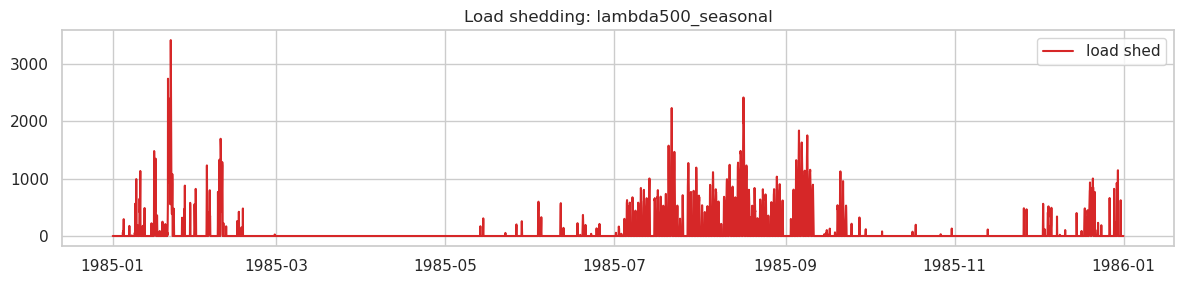

lambda500_seasonal – top 15 shedding buses


,bus_id,load_shedding
0,80,621042.437696
1,75,4118.751190
2,76,3356.468265
3,77,2223.858171
4,37,0.000000
5,38,0.000000
6,43,0.000000
7,44,0.000000
8,45,0.000000
9,46,0.000000


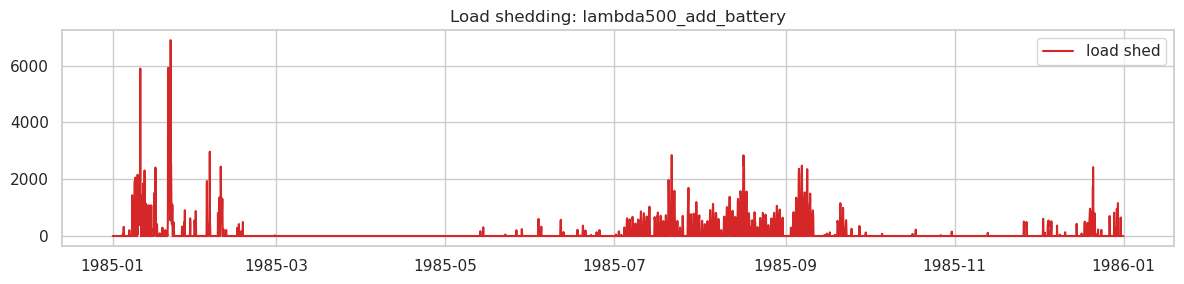

lambda500_add_battery – top 15 shedding buses


,bus_id,load_shedding
0,80,626672.612974
1,52,51505.360412
2,53,44813.509915
3,79,44734.584382
4,82,17773.420821
5,77,12318.414086
6,76,9995.772081
7,81,6164.250565
8,75,4338.265391
9,37,0.000000


In [22]:

for label, data in run_data.items():
    ls = total_ts(data["load_shed"], "load_shedding")
    fig, ax = plt.subplots(1, 1, figsize=(12,3))
    ax.plot(ls.index, ls.values, label="load shed", color="tab:red")
    ax.set_title(f"Load shedding: {label}")
    ax.legend()
    plt.tight_layout()
    plt.show()

    ls_bus = data["load_shed"].groupby("bus_id")["load_shedding"].sum().sort_values(ascending=False).head(15)
    print(f"{label} – top 15 shedding buses")
    display(ls_bus.reset_index())


## D) Curtailment (wind + solar)


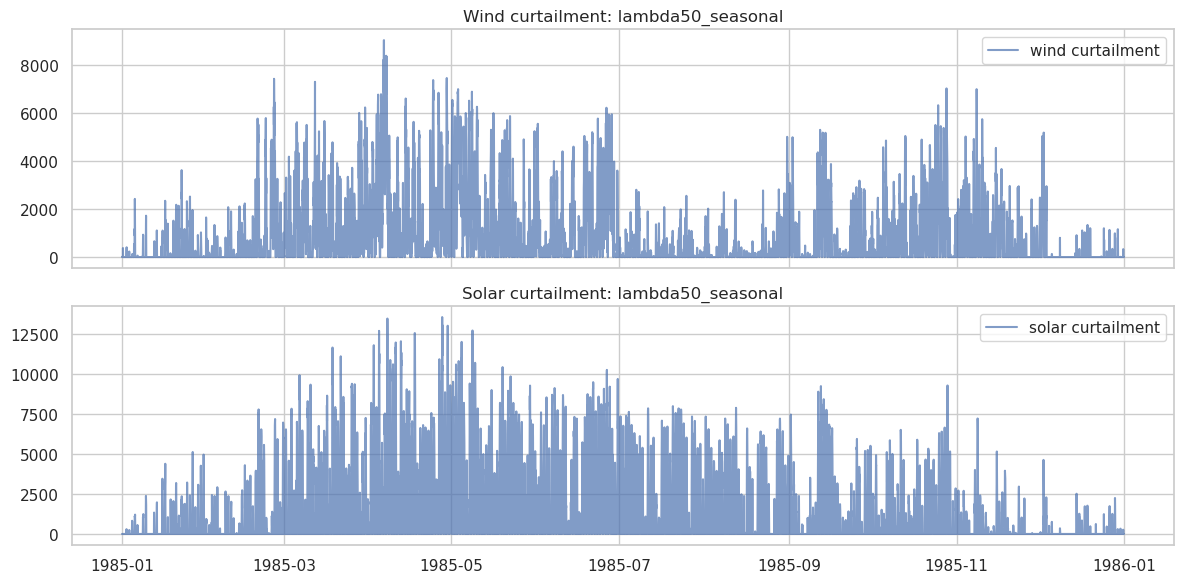

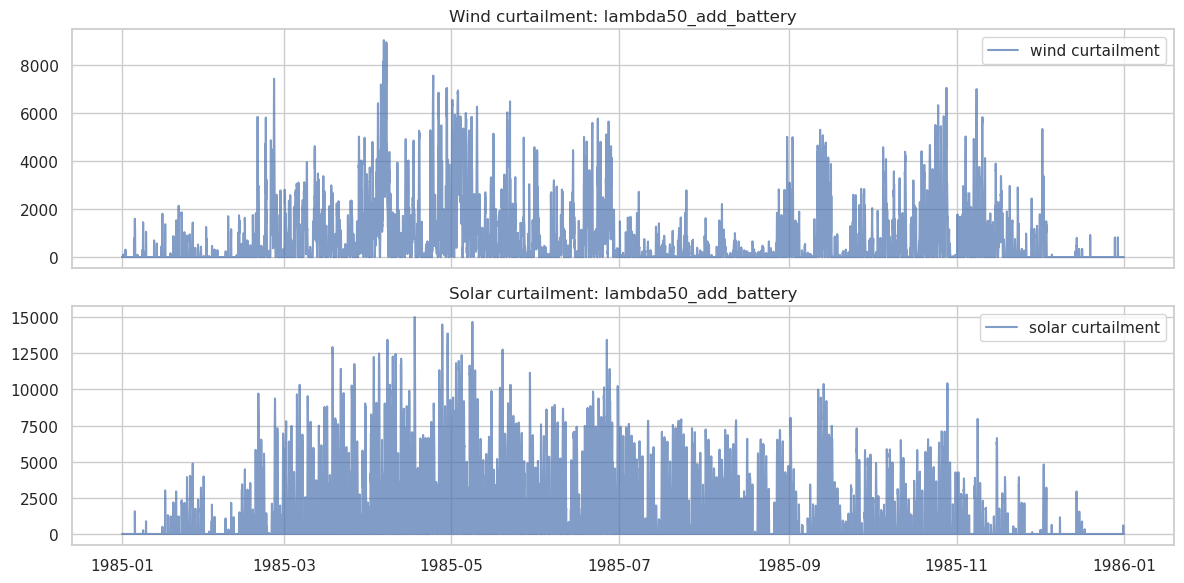

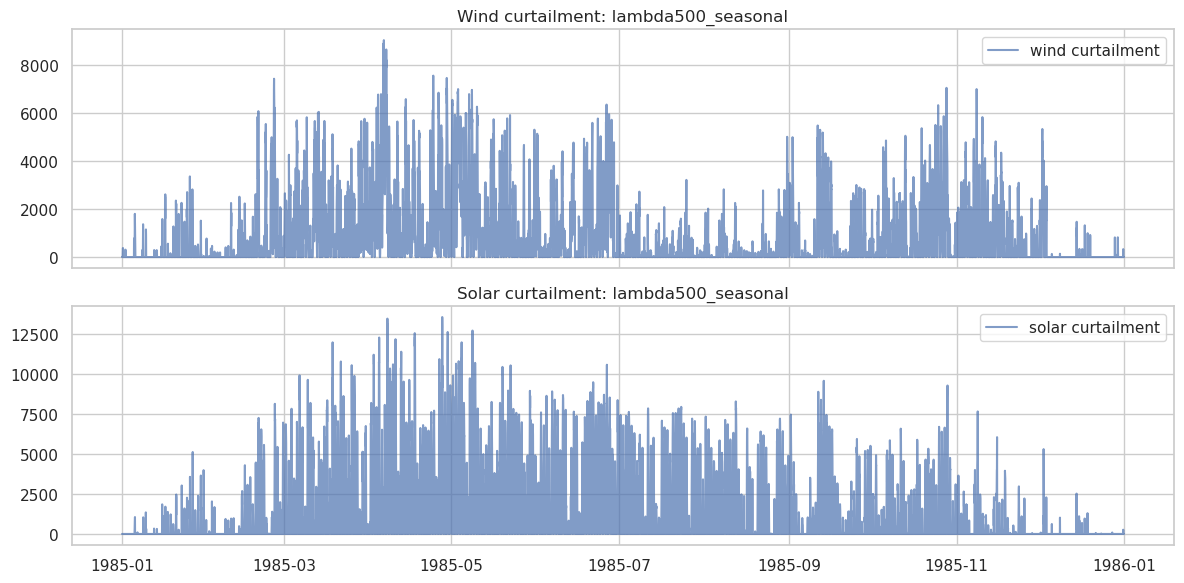

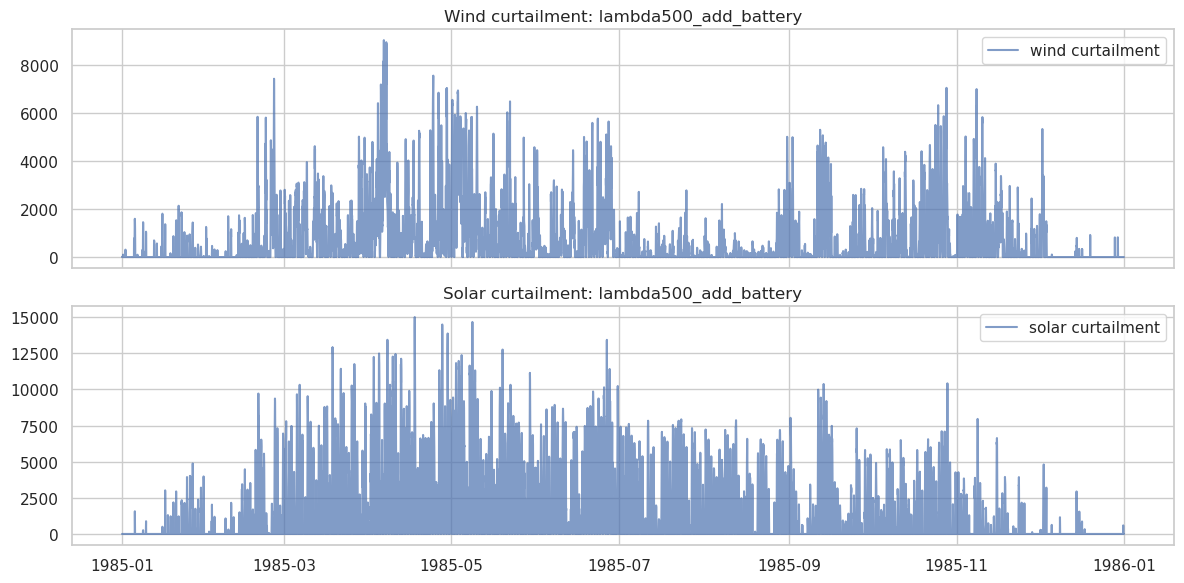

In [23]:

for label, data in run_data.items():
    wind = total_ts(data["wind_curt"], "wind_curtailment")
    solar = total_ts(data["solar_curt"], "solar_curtailment")

    fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)
    axes[0].plot(wind.index, wind.values, label="wind curtailment", alpha=0.7)
    axes[0].set_title(f"Wind curtailment: {label}")
    axes[0].legend()

    axes[1].plot(solar.index, solar.values, label="solar curtailment", alpha=0.7)
    axes[1].set_title(f"Solar curtailment: {label}")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## E) Seasonal SOC stats + monthly seasonality


,run,soc_max_MWh,soc_min_MWh,soc_end_MWh
0,lambda50_seasonal,3888121.13,3418615.48,3418615.48
1,lambda50_add_battery,NaN,NaN,NaN
2,lambda500_seasonal,3887931.29,3633040.42,3633040.42
3,lambda500_add_battery,NaN,NaN,NaN


Monthly net seasonal energy (MWh):


,lambda50_seasonal,lambda50_add_battery,lambda500_seasonal,lambda500_add_battery
1985-01-31 00:00:00,-242494.2,NaN,-149259.6,NaN
1985-02-28 00:00:00,-50529.8,NaN,-9065.5,NaN
1985-03-31 00:00:00,14568.9,NaN,0.0,NaN
1985-04-30 00:00:00,11328.2,NaN,0.0,NaN
1985-05-31 00:00:00,9845.8,NaN,0.0,NaN
1985-06-30 00:00:00,2951.3,NaN,-16.0,NaN
1985-07-31 00:00:00,-23502.9,NaN,-13144.3,NaN
1985-08-31 00:00:00,-28186.7,NaN,-19678.3,NaN
1985-09-30 00:00:00,-23107.9,NaN,-21157.4,NaN
1985-10-31 00:00:00,1122.5,NaN,-261.5,NaN


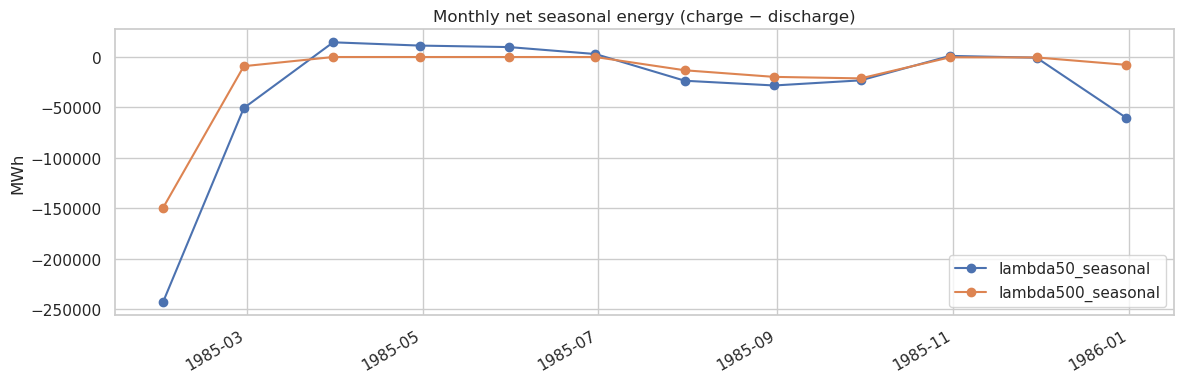

Monthly mean seasonal SOC (MWh):


,lambda50_seasonal,lambda50_add_battery,lambda500_seasonal,lambda500_add_battery
1985-01-31 00:00:00,3736401.6,NaN,3786136.1,NaN
1985-02-28 00:00:00,3558433.2,NaN,3707369.1,NaN
1985-03-31 00:00:00,3554095.8,NaN,3705113.1,NaN
1985-04-30 00:00:00,3565627.1,NaN,3705113.1,NaN
1985-05-31 00:00:00,3575715.2,NaN,3705113.1,NaN
1985-06-30 00:00:00,3578630.7,NaN,3705096.3,NaN
1985-07-31 00:00:00,3568525.8,NaN,3699762.3,NaN
1985-08-31 00:00:00,3533774.6,NaN,3678907.2,NaN
1985-09-30 00:00:00,3496397.7,NaN,3648659.0,NaN
1985-10-31 00:00:00,3488784.0,NaN,3642698.0,NaN


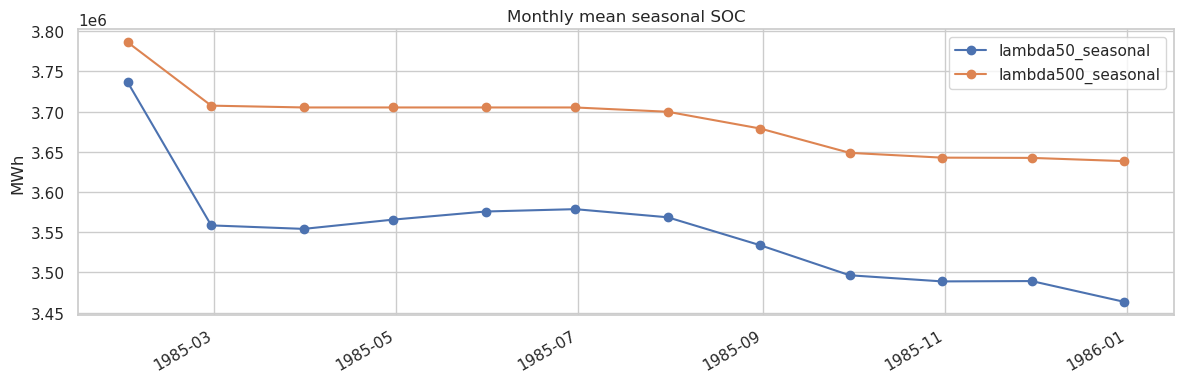

In [24]:

rows = []
for label, data in run_data.items():
    soc = data["soc_seasonal"]
    if soc.empty:
        rows.append({"run": label, "soc_max_MWh": np.nan, "soc_min_MWh": np.nan, "soc_end_MWh": np.nan})
        continue
    rows.append({
        "run": label,
        "soc_max_MWh": float(soc.max()),
        "soc_min_MWh": float(soc.min()),
        "soc_end_MWh": float(soc.iloc[-1]),
    })

soc_df = pd.DataFrame(rows)
for c in soc_df.columns[1:]:
    soc_df[c] = soc_df[c].round(2)

display(soc_df)

# Monthly net energy + SOC

def monthly_sum(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("ME").sum()


def monthly_mean(series: pd.Series) -> pd.Series:
    if series is None or len(series) == 0:
        return pd.Series(dtype=float)
    s = series.copy()
    s.index = _strip_tz(s.index)
    return s.resample("ME").mean()

monthly_net = {}
monthly_soc = {}
for label, data in run_data.items():
    seas_ch = total_ts(data["charge_seasonal"], "charge")
    seas_dis = total_ts(data["discharge_seasonal"], "discharge")
    net = seas_ch - seas_dis
    monthly_net[label] = monthly_sum(net)
    monthly_soc[label] = monthly_mean(data["soc_seasonal"])

monthly_net_df = pd.DataFrame(monthly_net).sort_index()
monthly_soc_df = pd.DataFrame(monthly_soc).sort_index()

print("Monthly net seasonal energy (MWh):")
display(monthly_net_df.round(1))

plot_net = monthly_net_df.dropna(how="all", axis=1)
if not plot_net.empty:
    ax = plot_net.plot(figsize=(12,4), marker='o', title="Monthly net seasonal energy (charge − discharge)")
    ax.set_ylabel("MWh")
    plt.tight_layout()
    plt.show()

print("Monthly mean seasonal SOC (MWh):")
display(monthly_soc_df.round(1))

plot_soc = monthly_soc_df.dropna(how="all", axis=1)
if not plot_soc.empty:
    ax = plot_soc.plot(figsize=(12,4), marker='o', title="Monthly mean seasonal SOC")
    ax.set_ylabel("MWh")
    plt.tight_layout()
    plt.show()
